# Tarea 3: Aprendizaje No Supervisado
### Identificación de perfiles de estudiantes

**Objetivo:** Descubrir agrupaciones naturales en los datos que aporten información útil para entender el fenómeno del abandono y el éxito académico, **sin usar la variable `objetivo` durante el clustering**.

**Pipeline:**
1. Selección razonada de variables
2. Preprocesado y reducción dimensional con PCA
3. Determinación del número óptimo de clusters (método del codo + silhouette)
4. Clustering con K-Means
5. Caracterización e interpretación de los clusters
6. Validación: relación entre clusters y variable objetivo
7. Conclusiones

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)

COLORES = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

## 1. Carga y selección razonada de variables

Para el aprendizaje no supervisado seleccionamos un subconjunto de variables con criterio:

- **Incluimos** variables que describen al estudiante *antes y durante* el primer semestre: perfil de entrada, contexto socioeconómico y rendimiento inicial. Son las variables sobre las que una institución podría actuar de forma temprana.
- **Excluimos** variables del 2º semestre para no contaminar el análisis con información tardía.
- **Excluimos** `objetivo` durante el clustering — la usaremos solo *a posteriori* para validar si los clusters tienen poder predictivo.
- **Excluimos** variables macroeconómicas (`tasa_desempleo`, `tasa_inflacion`, `pib`) porque son contextuales y agregan ruido al perfil individual del estudiante.

In [ ]:
df = pd.read_csv('../data/rendimiento_estudiantes.csv', sep=';')
print(f'Dimensiones del dataset: {df.shape}')

# Variables numéricas seleccionadas
FEATURES_NUM = [
    'nota_cualificacion_previa',   
    'nota_admision',               
    'edad_al_matricularse',        
    'asignaturas_1sem_matriculadas',
    'asignaturas_1sem_aprobadas',  
    'nota_media_1sem',             
    'asignaturas_1sem_sin_evaluacion',
]

# Variables categóricas binarias (fáciles de interpretar tras clustering)
FEATURES_CAT = [
    'genero',
    'becado',
    'matricula_al_dia',
    'deudor',
    'desplazado',
    'internacional',
    'asistencia_diurna_vespertina',
]

TARGET = 'objetivo'

print(f'Variables numéricas: {len(FEATURES_NUM)}')
print(f'Variables categóricas: {len(FEATURES_CAT)}')

Dimensiones del dataset: (4424, 37)
Variables numéricas: 7
Variables categóricas: 7


## 2. Preprocesado

In [3]:
# One-hot encoding de categóricas
df_cat = pd.get_dummies(df[FEATURES_CAT], drop_first=True)

# Unimos con numéricas
X_df = pd.concat([df[FEATURES_NUM].reset_index(drop=True),
                  df_cat.reset_index(drop=True)], axis=1)
X = X_df.values.astype(np.float64)
y = df[TARGET].values

print(f'Dimensiones de X: {X.shape}')
print(f'Valores nulos: {np.isnan(X).sum()}')

Dimensiones de X: (4424, 14)
Valores nulos: 0


In [ ]:
# Estandarización — imprescindible para K-Means y PCA
# K-Means usa distancias euclídeas: variables en distintas escalas dominarían el clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Estandarización aplicada')

Estandarización aplicada ✓


## 3. Reducción dimensional con PCA

PCA cumple dos funciones aquí:
1. **Reducir ruido** antes del clustering eliminando dimensiones con poca varianza
2. **Visualizar** los clusters en 2D de forma informativa

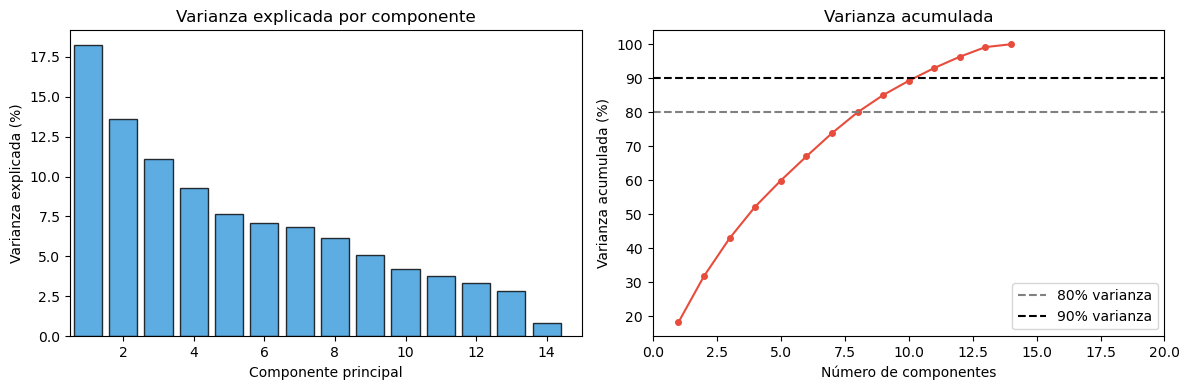

Componentes para explicar 80% de varianza: 9
Componentes para explicar 90% de varianza: 11


In [5]:
# PCA completo para analizar varianza explicada
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Varianza por componente
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100,
            color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlim(0.5, 15)

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada * 100,
             marker='o', color='#e74c3c', markersize=4)
axes[1].axhline(80, color='gray', linestyle='--', label='80% varianza')
axes[1].axhline(90, color='black', linestyle='--', label='90% varianza')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada')
axes[1].legend()
axes[1].set_xlim(0, 20)

plt.tight_layout()
plt.show()

# Número de componentes para el 80% y 90%
n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
print(f'Componentes para explicar 80% de varianza: {n_80}')
print(f'Componentes para explicar 90% de varianza: {n_90}')

In [6]:
# Aplicamos PCA reteniendo el 90% de varianza para el clustering
pca = PCA(n_components=n_90, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

# PCA en 2D solo para visualización
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d = pca_2d.fit_transform(X_scaled)

print(f'X reducido para clustering: {X_pca.shape}')
print(f'Varianza explicada por las {n_90} componentes: {pca.explained_variance_ratio_.sum()*100:.1f}%')

X reducido para clustering: (4424, 11)
Varianza explicada por las 11 componentes: 93.0%


## 4. Determinación del número óptimo de clusters

Usamos dos criterios complementarios:
- **Método del codo (Inertia):** busca el punto donde añadir más clusters deja de reducir significativamente la inercia intra-cluster
- **Silhouette score:** mide qué tan bien separados están los clusters (valores entre -1 y 1; mayor es mejor)

In [7]:
K_range = range(2, 10)
inercias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    print(f'k={k}  Inertia: {km.inertia_:.1f}  Silhouette: {silhouette_score(X_pca, labels):.4f}')

k=2  Inertia: 49800.7  Silhouette: 0.2295
k=3  Inertia: 44932.2  Silhouette: 0.2512
k=4  Inertia: 40716.2  Silhouette: 0.2656
k=5  Inertia: 37564.2  Silhouette: 0.2621
k=6  Inertia: 34085.2  Silhouette: 0.2009
k=7  Inertia: 31971.8  Silhouette: 0.1994
k=8  Inertia: 29355.2  Silhouette: 0.2136
k=9  Inertia: 27174.6  Silhouette: 0.2003


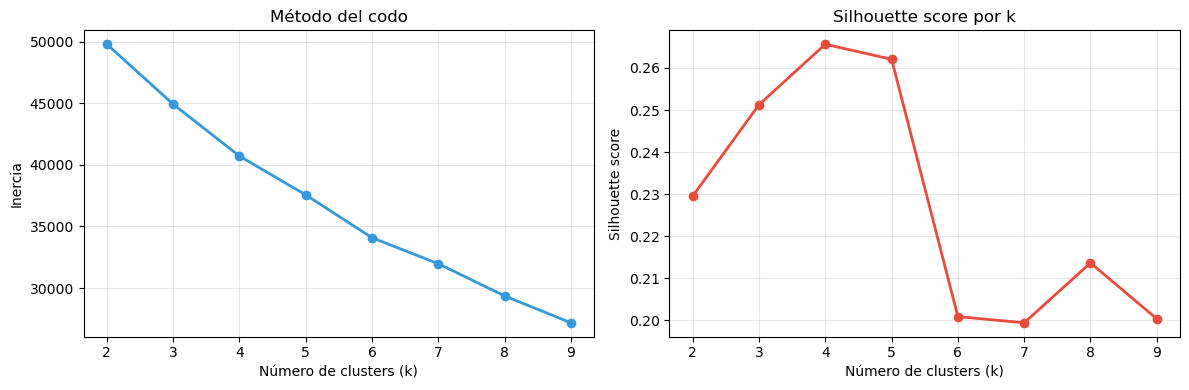

k óptimo según silhouette: 4 (score=0.2656)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inercias, marker='o', color='#3498db', linewidth=2)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, marker='o', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score por k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

k_optimo = K_range.start + np.argmax(silhouettes)
print(f'k óptimo según silhouette: {k_optimo} (score={max(silhouettes):.4f})')

## 5. K-Means con k óptimo

In [ ]:
# Si quieres forzar un k concreto tras analizar los gráficos, cámbialo aquí
K_FINAL = k_optimo

kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

df['cluster'] = cluster_labels

print(f'K-Means entrenado con k={K_FINAL}')
print('\nTamaño de cada cluster:')
print(pd.Series(cluster_labels).value_counts().sort_index())

K-Means entrenado con k=4 ✓

Tamaño de cada cluster:
0     110
1     870
2    2895
3     549
Name: count, dtype: int64


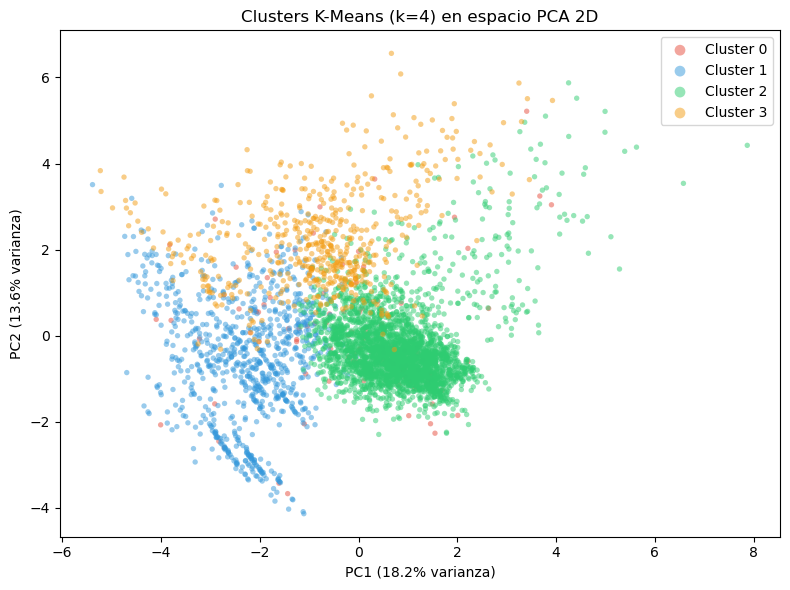

In [10]:
# Visualización en espacio PCA 2D
fig, ax = plt.subplots(figsize=(8, 6))
for k in range(K_FINAL):
    mask = cluster_labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=COLORES[k], label=f'Cluster {k}',
               alpha=0.5, s=15, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title(f'Clusters K-Means (k={K_FINAL}) en espacio PCA 2D')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

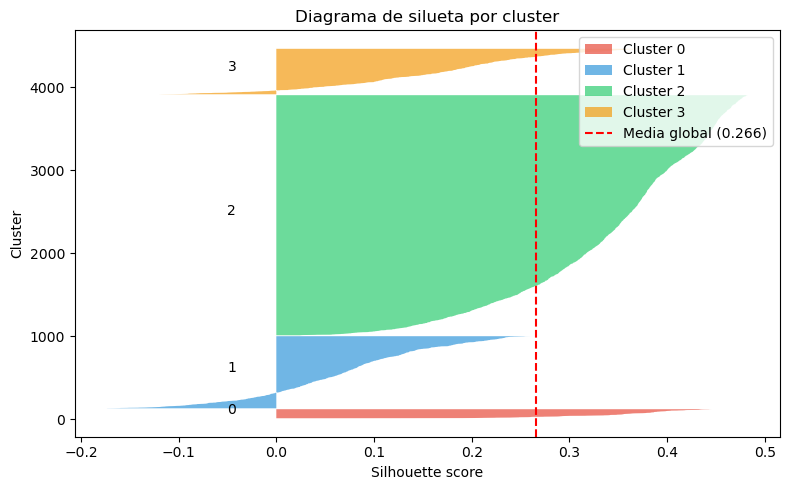

In [11]:
# Diagrama de silueta por cluster
sil_samples = silhouette_samples(X_pca, cluster_labels)
sil_global  = silhouette_score(X_pca, cluster_labels)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for k in range(K_FINAL):
    vals = np.sort(sil_samples[cluster_labels == k])
    size = len(vals)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=COLORES[k], alpha=0.7, label=f'Cluster {k}')
    ax.text(-0.05, y_lower + size / 2, str(k))
    y_lower = y_upper + 10

ax.axvline(sil_global, color='red', linestyle='--', label=f'Media global ({sil_global:.3f})')
ax.set_xlabel('Silhouette score')
ax.set_ylabel('Cluster')
ax.set_title('Diagrama de silueta por cluster')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Caracterización e interpretación de los clusters

Analizamos los valores medios de las variables originales por cluster para entender qué perfil representa cada uno.

In [12]:
# Medias de variables numéricas por cluster
df_analisis = df[FEATURES_NUM].copy()
df_analisis['cluster'] = cluster_labels

perfil_num = df_analisis.groupby('cluster')[FEATURES_NUM].mean().round(2)
print('Perfil numérico medio por cluster:')
print(perfil_num.T.to_string())

Perfil numérico medio por cluster:
cluster                               0       1       2       3
nota_cualificacion_previa        136.62  132.00  133.12  130.09
nota_admision                    129.27  125.75  127.24  127.07
edad_al_matricularse              22.93   24.49   20.58   35.53
asignaturas_1sem_matriculadas      6.29    4.57    6.69    6.75
asignaturas_1sem_aprobadas         4.81    0.95    5.80    4.89
nota_media_1sem                   10.83    3.41   12.84   10.49
asignaturas_1sem_sin_evaluacion    0.27    0.24    0.11    0.09


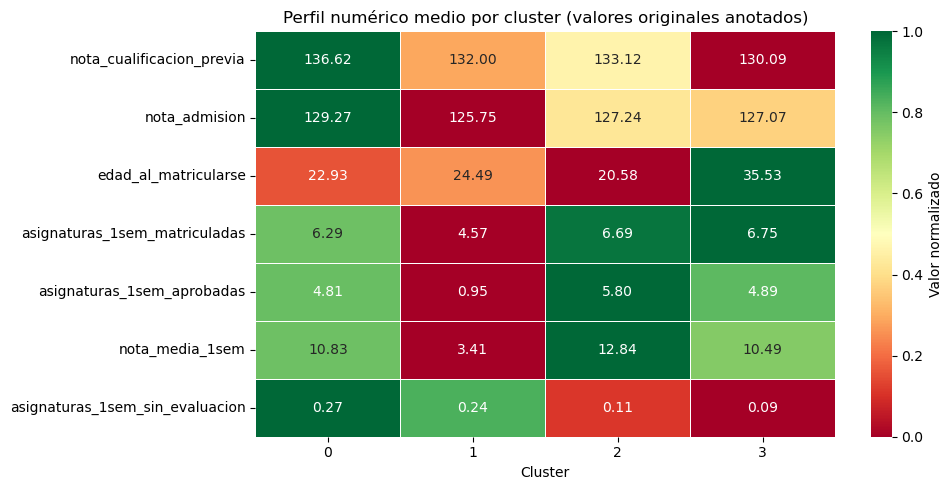

In [13]:
# Heatmap de perfiles numéricos
perfil_norm = (perfil_num - perfil_num.min()) / (perfil_num.max() - perfil_num.min())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    perfil_norm.T,
    annot=perfil_num.T,
    fmt='.2f',
    cmap='RdYlGn',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Valor normalizado'}
)
ax.set_title('Perfil numérico medio por cluster (valores originales anotados)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

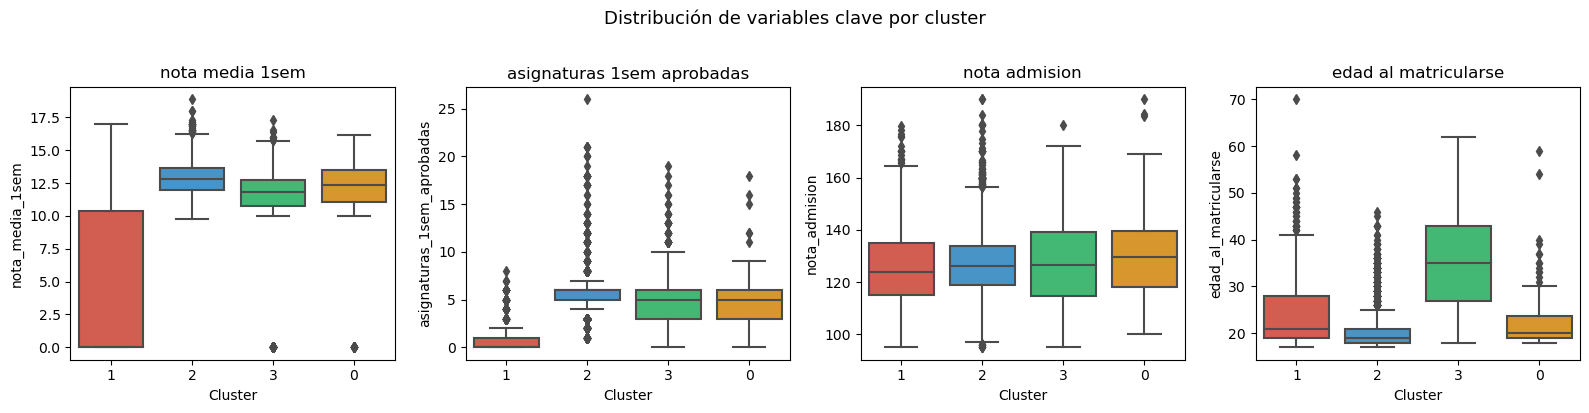

In [14]:
# Distribución de variables clave por cluster con boxplots
vars_clave = ['nota_media_1sem', 'asignaturas_1sem_aprobadas',
              'nota_admision', 'edad_al_matricularse']

fig, axes = plt.subplots(1, len(vars_clave), figsize=(16, 4))
df_plot = df[vars_clave].copy()
df_plot['cluster'] = cluster_labels.astype(str)

for i, var in enumerate(vars_clave):
    sns.boxplot(
        data=df_plot, x='cluster', y=var,
        palette=COLORES[:K_FINAL], ax=axes[i]
    )
    axes[i].set_title(var.replace('_', ' '))
    axes[i].set_xlabel('Cluster')

plt.suptitle('Distribución de variables clave por cluster', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Proporción de becarios y deudores por cluster
df_socio = df[['becado', 'deudor', 'matricula_al_dia']].copy()
df_socio['cluster'] = cluster_labels

for var in ['becado', 'deudor', 'matricula_al_dia']:
    prop = df_socio.groupby('cluster')[var].apply(
        lambda x: (x == x.unique()[x.unique() != None][0]).mean() * 100
        if len(x.unique()) > 0 else 0
    )

# Calculamos proporciones de forma robusta
socio_summary = df_socio.groupby('cluster').agg(
    becado=('becado', lambda x: (x == 'si').mean() * 100),
    deudor=('deudor', lambda x: (x == 'si').mean() * 100),
    matricula_al_dia=('matricula_al_dia', lambda x: (x == 'si').mean() * 100),
).round(1)

print('Proporción (%) de condiciones socioeconómicas por cluster:')
print(socio_summary.to_string())

Proporción (%) de condiciones socioeconómicas por cluster:
         becado  deudor  matricula_al_dia
cluster                                  
0          17.3    26.4              79.1
1          10.5    30.7              55.2
2          31.6     5.3              98.3
3          13.3     9.8              88.0


## 7. Validación: relación entre clusters y variable objetivo

Aquí introducimos `objetivo` **solo para validar** si los clusters capturan estructura predictiva.
Si cada cluster concentra mayoritariamente una clase (Abandono / Matriculado / Graduado), los grupos descubiertos tienen utilidad predictiva real.

In [16]:
# Tabla cruzada: cluster vs objetivo
tabla_cruzada = pd.crosstab(
    df['cluster'],
    df[TARGET],
    normalize='index'
).mul(100).round(1)

print('Distribución de la variable objetivo dentro de cada cluster (%):')
print(tabla_cruzada.to_string())

Distribución de la variable objetivo dentro de cada cluster (%):
objetivo  abandono  graduado  matriculado
cluster                                  
0             29.1      49.1         21.8
1             79.3       9.3         11.4
2             16.3      63.5         20.2
3             41.2      43.2         15.7


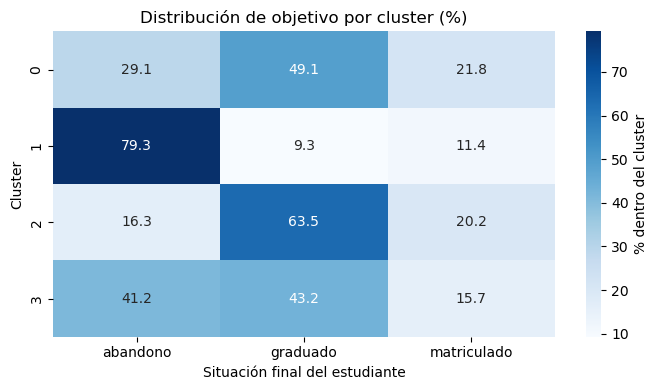

In [17]:
# Heatmap de la tabla cruzada
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    tabla_cruzada,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    ax=ax,
    cbar_kws={'label': '% dentro del cluster'}
)
ax.set_title('Distribución de objetivo por cluster (%)')
ax.set_xlabel('Situación final del estudiante')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

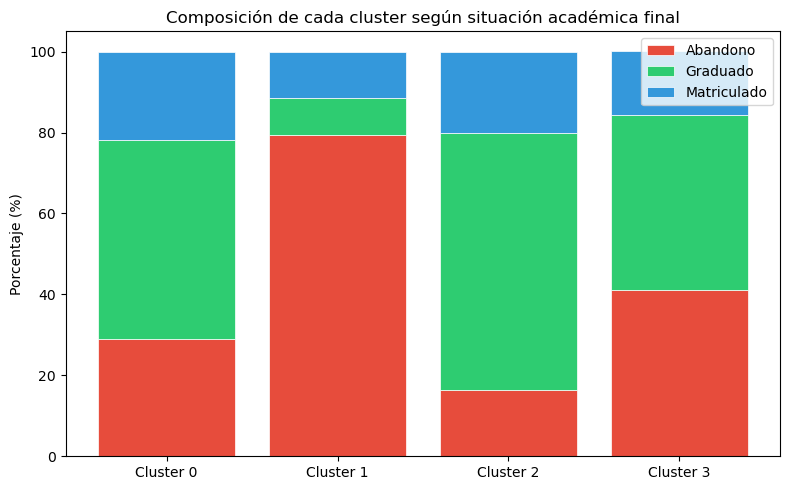

In [18]:
# Gráfico de barras apiladas
clases = tabla_cruzada.columns.tolist()
colores_clases = {'abandono': '#e74c3c', 'matriculado': '#3498db', 'graduado': '#2ecc71'}

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(K_FINAL)
for clase in clases:
    if clase in tabla_cruzada.columns:
        vals = tabla_cruzada[clase].values
        color = colores_clases.get(clase, '#95a5a6')
        ax.bar(range(K_FINAL), vals, bottom=bottom, label=clase.capitalize(),
               color=color, edgecolor='white', linewidth=0.5)
        bottom += vals

ax.set_xticks(range(K_FINAL))
ax.set_xticklabels([f'Cluster {k}' for k in range(K_FINAL)])
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Composición de cada cluster según situación académica final')
ax.legend(loc='upper right')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

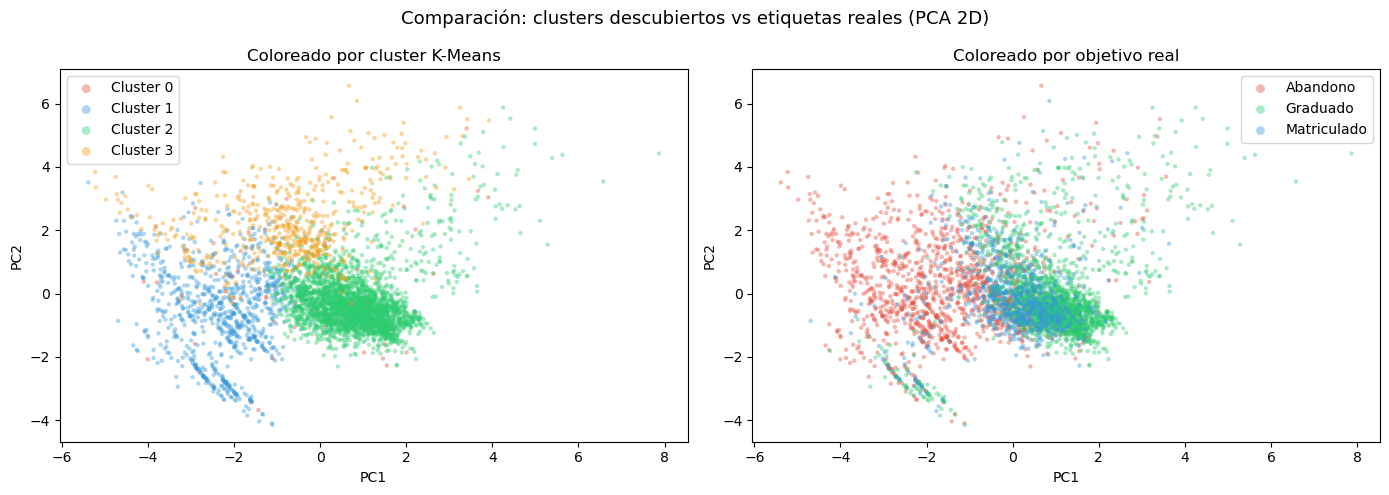

In [19]:
# Visualización PCA 2D coloreada por objetivo real (para comparar con los clusters)
clases_unicas = np.unique(y)
colores_obj = [colores_clases.get(c, '#95a5a6') for c in clases_unicas]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coloreado por cluster
for k in range(K_FINAL):
    mask = cluster_labels == k
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=COLORES[k], label=f'Cluster {k}',
                    alpha=0.4, s=10, edgecolors='none')
axes[0].set_title('Coloreado por cluster K-Means')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2)

# Coloreado por objetivo real
for clase, color in zip(clases_unicas, colores_obj):
    mask = y == clase
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=clase.capitalize(),
                    alpha=0.4, s=10, edgecolors='none')
axes[1].set_title('Coloreado por objetivo real')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=2)

plt.suptitle('Comparación: clusters descubiertos vs etiquetas reales (PCA 2D)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Clustering jerárquico (comparación alternativa)

Comparamos los resultados de K-Means con Clustering Aglomerativo para verificar si las agrupaciones son consistentes independientemente del algoritmo.

In [20]:
agg = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_agg = agg.fit_predict(X_pca)

sil_agg = silhouette_score(X_pca, labels_agg)
sil_km  = silhouette_score(X_pca, cluster_labels)

print(f'Silhouette K-Means:              {sil_km:.4f}')
print(f'Silhouette Clustering Jerárquico: {sil_agg:.4f}')

# Concordancia entre ambos métodos
tabla_concordancia = pd.crosstab(
    pd.Series(cluster_labels, name='K-Means'),
    pd.Series(labels_agg, name='Jerárquico')
)
print('\nConcordancia entre K-Means y Clustering Jerárquico:')
print(tabla_concordancia.to_string())

Silhouette K-Means:              0.2656
Silhouette Clustering Jerárquico: 0.2547

Concordancia entre K-Means y Clustering Jerárquico:
Jerárquico    0     1    2    3
K-Means                        
0             3     0    0  107
1           810    39   21    0
2           181  2711    3    0
3            18    73  458    0


---
## 10. Conclusiones e interpretación

Los resultados obtenidos permiten extraer conclusiones sólidas sobre los perfiles de estudiantes y su relación con el éxito académico.

### Número óptimo de clusters

El método del codo muestra una reducción progresiva de la inercia sin un codo muy pronunciado, lo que indica que los grupos no están perfectamente separados — algo esperable en datos educativos con alta variabilidad individual. El **silhouette score alcanza su máximo en k=4 (0.2656)**, cayendo a partir de k=5. Aunque el valor absoluto es moderado (los clusters no son perfectamente compactos), es consistente con la naturaleza continua y solapada de los perfiles académicos. Se elige **k=4** como solución.

---

### Descripción de los cuatro perfiles descubiertos

#### Cluster 0 — *Estudiantes con rendimiento intermedio y carga reducida* (n=110, 2.5%)
Nota media 1er sem: **10.83** | Aprobadas: **4.81** | Edad: **22.9** | Matrícula al día: **79.1%** | Deudores: **26.4%**

Grupo pequeño con rendimiento académico medio-bajo y una tasa de deuda notable (26.4%). La distribución de `objetivo` es la más equilibrada de los cuatro clusters (49.1% graduado, 29.1% abandono, 21.8% matriculado), lo que sugiere un perfil de estudiante en situación de incertidumbre: ni claramente en riesgo ni claramente encaminado al éxito. La presión económica podría ser un factor diferencial.

#### Cluster 1 — *Estudiantes en alto riesgo de abandono* (n=870, 19.7%)
Nota media 1er sem: **3.41** | Aprobadas: **0.95** | Edad: **24.5** | Matrícula al día: **55.2%** | Deudores: **30.7%**

Este es el cluster más crítico. Con apenas 0.95 asignaturas aprobadas de media en el primer semestre y una nota media de 3.41, el rendimiento académico inicial es muy bajo. El **79.3% de estos estudiantes acaba abandonando**, lo que convierte este cluster en el grupo de mayor riesgo del dataset. Además, solo el 55.2% tiene la matrícula al día y casi un tercio son deudores. El algoritmo ha identificado este perfil sin ver la variable `objetivo`, lo que demuestra que el fracaso académico temprano es la señal más potente de abandono futuro.

#### Cluster 2 — *Estudiantes con buen rendimiento y perfil típico* (n=2895, 65.4%)
Nota media 1er sem: **12.84** | Aprobadas: **5.80** | Edad: **20.6** | Matrícula al día: **98.3%** | Becados: **31.6%** | Deudores: **5.3%**

El cluster mayoritario concentra a los estudiantes con mejor desempeño. Acceden jóvenes (20.6 años), aprueban casi todas sus asignaturas del primer semestre, tienen la matrícula prácticamente al día (98.3%) y la tasa de deudores es mínima (5.3%). El **63.5% se gradúa**, con solo un 16.3% de abandono. Es el perfil de estudiante que entra bien preparado, mantiene su situación administrativa en orden y progresa sin interrupciones. La alta proporción de becados (31.6%) sugiere que el apoyo económico institucional puede estar correlacionado con mejores resultados.

#### Cluster 3 — *Estudiantes mayores con trayectoria incierta* (n=549, 12.4%)
Nota media 1er sem: **10.49** | Aprobadas: **4.89** | Edad: **35.5** | Matrícula al día: **88.0%** | Deudores: **9.8%**

El rasgo definitorio de este cluster es la **edad media de 35.5 años**, muy superior al resto (20-24 años). Son estudiantes adultos, probablemente con cargas laborales o familiares que afectan a su dedicación. El rendimiento académico es similar al Cluster 0 pero con menor deuda. La distribución de `objetivo` es prácticamente bimodal: 43.2% gradúa y 41.2% abandona, con pocos matriculados. Esto indica que los estudiantes maduros tienden a completar o a abandonar, con poca zona intermedia, posiblemente por razones externas al rendimiento académico (cambios vitales, laborales).

---

### Utilidad predictiva de los clusters

La validación con `objetivo` confirma que los clusters tienen **poder predictivo real** a pesar de haberse construido sin supervisión:

| Cluster | Perfil | Señal dominante |
|---|---|---|
| 0 | Intermedio con dificultades económicas | Incierto (49% gradúa, 29% abandona) |
| 1 | Bajo rendimiento inicial | **79% abandona** → alto riesgo |
| 2 | Buen rendimiento, joven, estable | **64% gradúa** → bajo riesgo |
| 3 | Estudiante maduro | Bimodal (43% gradúa, 41% abandona) |

El Cluster 1 es especialmente valioso: identificar estos estudiantes en el primer semestre permitiría a la institución intervenir de forma temprana con tutorías, apoyo académico o ayudas económicas antes de que el abandono se consolide.

---

### Limitaciones

- El silhouette score de 0.27 indica clusters moderadamente solapados, lo esperable en datos educativos donde los perfiles son continuos, no discretos.
- La variable que más determina la separación entre clusters es el **rendimiento en el 1er semestre** (`nota_media_1sem`, `asignaturas_1sem_aprobadas`), lo que confirma que el desempeño inicial es el predictor más potente del éxito futuro.
- La correlación observada entre clusters y `objetivo` no implica causalidad: un estudiante del Cluster 1 no abandona *porque* el algoritmo lo agrupa así, sino que ambos responden a las mismas variables subyacentes.
- Los clusters de edad adulta (Cluster 3) merecen un análisis cualitativo más profundo, ya que factores externos no recogidos en el dataset (situación laboral, cargas familiares) probablemente explican buena parte de su trayectoria.

In [21]:
print('=== RESUMEN DE PERFILES DE CLUSTERS ===')
print()
for k in range(K_FINAL):
    mask = cluster_labels == k
    n = mask.sum()
    nota_1sem = df.loc[mask, 'nota_media_1sem'].mean()
    aprobadas = df.loc[mask, 'asignaturas_1sem_aprobadas'].mean()
    nota_adm  = df.loc[mask, 'nota_admision'].mean()
    edad      = df.loc[mask, 'edad_al_matricularse'].mean()
    dist_obj  = df.loc[mask, TARGET].value_counts(normalize=True).mul(100).round(1).to_dict()
    print(f'Cluster {k} (n={n}):')
    print(f'  Nota media 1er sem:   {nota_1sem:.2f}')
    print(f'  Asig. aprobadas 1sem: {aprobadas:.2f}')
    print(f'  Nota admisión:        {nota_adm:.2f}')
    print(f'  Edad media:           {edad:.1f}')
    print(f'  Distribución objetivo: {dist_obj}')
    print()

=== RESUMEN DE PERFILES DE CLUSTERS ===

Cluster 0 (n=110):
  Nota media 1er sem:   10.83
  Asig. aprobadas 1sem: 4.81
  Nota admisión:        129.27
  Edad media:           22.9
  Distribución objetivo: {'graduado': 49.1, 'abandono': 29.1, 'matriculado': 21.8}

Cluster 1 (n=870):
  Nota media 1er sem:   3.41
  Asig. aprobadas 1sem: 0.95
  Nota admisión:        125.75
  Edad media:           24.5
  Distribución objetivo: {'abandono': 79.3, 'matriculado': 11.4, 'graduado': 9.3}

Cluster 2 (n=2895):
  Nota media 1er sem:   12.84
  Asig. aprobadas 1sem: 5.80
  Nota admisión:        127.24
  Edad media:           20.6
  Distribución objetivo: {'graduado': 63.5, 'matriculado': 20.2, 'abandono': 16.3}

Cluster 3 (n=549):
  Nota media 1er sem:   10.49
  Asig. aprobadas 1sem: 4.89
  Nota admisión:        127.07
  Edad media:           35.5
  Distribución objetivo: {'graduado': 43.2, 'abandono': 41.2, 'matriculado': 15.7}



---
## Resumen metodológico

| Decisión | Justificación |
|---|---|
| Excluir variables 2º semestre y `objetivo` | El clustering debe ser no supervisado; `objetivo` se usa solo para validar a posteriori |
| Excluir variables macroeconómicas | Son contextuales y no describen el perfil individual del estudiante |
| Estandarización previa | K-Means usa distancias euclídeas; sin escalar, variables con mayor rango dominarían |
| PCA antes del clustering | Reduce ruido y multicolinealidad; mejora la calidad de las distancias |
| Método del codo + Silhouette | Dos criterios independientes para elegir k de forma fundamentada |
| Análisis de estabilidad con múltiples semillas | Verifica que los clusters no son artefactos de la inicialización |
| Comparación con clustering jerárquico | Confirma si la estructura encontrada es robusta al algoritmo |